# Pablo Prol Prieto and Pablo Sala Fernández (Team Pablo(s) in Kaggle)
## Session2 notebook

## Imports and setup

In [185]:
# some imports
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12)
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# create output folder
if not os.path.exists('output'):
    os.makedirs('output')
if not os.path.exists('output/session2'):
    os.makedirs('output/session2')

# to make this notebook's output identical at every run
np.random.seed(42)

## Load data

In [186]:
housing = pd.read_csv('train_set.csv',index_col=0)

## Data exploration

In [187]:
housing.shape

(5432, 21)

In [188]:
housing.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
index,,,,,,,,,,,,,,,,,,,,,
0,Aberfeldie,241 Buckley St,4,h,1380000.0,VB,Nelson,12/08/2017,7.5,3040.0,4.0,2.0,2.0,766.0,NaN,NaN,Moonee Valley,-37.75595,144.90551,Western Metropolitan,1543.0
1,Northcote,67 Charles St,2,h,1100000.0,SP,Jellis,20/05/2017,5.5,3070.0,2.0,1.0,1.0,189.0,NaN,NaN,Darebin,-37.77670,144.99240,Northern Metropolitan,11364.0
2,Balwyn North,42 Maud St,3,h,1480000.0,PI,Jellis,15/10/2016,9.2,3104.0,3.0,1.0,4.0,605.0,116.0,1950.0,Boroondara,-37.79510,145.06960,Southern Metropolitan,7809.0
3,Brunswick,13 Percy St,3,h,1055000.0,S,Nelson,7/05/2016,5.2,3056.0,3.0,1.0,1.0,324.0,NaN,1930.0,Moreland,-37.76530,144.95860,Northern Metropolitan,11918.0
4,Templestowe Lower,253 Thompsons Rd,4,h,1000000.0,VB,hockingstuart,13/08/2016,13.8,3107.0,4.0,3.0,2.0,728.0,164.0,1970.0,Manningham,-37.76800,145.10270,Eastern Metropolitan,5420.0


In [189]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5432 entries, 0 to 5431
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         5432 non-null   object 
 1   Address        5432 non-null   object 
 2   Rooms          5432 non-null   int64  
 3   Type           5432 non-null   object 
 4   Price          5432 non-null   float64
 5   Method         5432 non-null   object 
 6   SellerG        5432 non-null   object 
 7   Date           5432 non-null   object 
 8   Distance       5432 non-null   float64
 9   Postcode       5432 non-null   float64
 10  Bedroom2       5432 non-null   float64
 11  Bathroom       5432 non-null   float64
 12  Car            5407 non-null   float64
 13  Landsize       5432 non-null   float64
 14  BuildingArea   2890 non-null   float64
 15  YearBuilt      3302 non-null   float64
 16  CouncilArea    4879 non-null   object 
 17  Lattitude      5432 non-null   float64
 18  Longtitude   

We can see that there are some NaN values in the following features: 'Car', 'BuildingArea', 'YearBuilt', 'CouncilArea'! We will have to deal with them later.

In [190]:
housing.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,5432.000000,5.432000e+03,5432.000000,5432.000000,5432.000000,5432.000000,5407.000000,5432.000000,2890.000000,3302.000000,5432.000000,5432.000000,5432.000000
mean,2.937224,1.078470e+06,10.220692,3106.552835,2.917342,1.538660,1.630109,537.054676,163.462430,1965.219564,-37.809664,144.995491,7438.537555
std,0.951947,6.470654e+05,5.996967,95.185290,0.988414,0.704286,0.982855,1550.867601,843.189116,36.244398,0.079365,0.106382,4368.906756
min,1.000000,1.450000e+05,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1830.000000,-38.174880,144.542370,389.000000
25%,2.000000,6.500000e+05,6.200000,3046.000000,2.000000,1.000000,1.000000,182.750000,92.000000,1940.000000,-37.856648,144.930800,4294.000000
50%,3.000000,9.015000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,450.000000,125.000000,1970.000000,-37.802635,145.000250,6543.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,654.250000,174.750000,1999.000000,-37.757238,145.059225,10331.000000
max,8.000000,8.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,75100.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Postcode is not numeric, we should change it to categorical.


In [191]:
housing['Postcode'] = pd.Categorical(housing.Postcode)
housing.describe()

,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,5432.000000,5.432000e+03,5432.000000,5432.000000,5432.000000,5407.000000,5432.000000,2890.000000,3302.000000,5432.000000,5432.000000,5432.000000
mean,2.937224,1.078470e+06,10.220692,2.917342,1.538660,1.630109,537.054676,163.462430,1965.219564,-37.809664,144.995491,7438.537555
std,0.951947,6.470654e+05,5.996967,0.988414,0.704286,0.982855,1550.867601,843.189116,36.244398,0.079365,0.106382,4368.906756
min,1.000000,1.450000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1830.000000,-38.174880,144.542370,389.000000
25%,2.000000,6.500000e+05,6.200000,2.000000,1.000000,1.000000,182.750000,92.000000,1940.000000,-37.856648,144.930800,4294.000000
50%,3.000000,9.015000e+05,9.200000,3.000000,1.000000,2.000000,450.000000,125.000000,1970.000000,-37.802635,145.000250,6543.000000
75%,3.000000,1.330000e+06,13.000000,3.000000,2.000000,2.000000,654.250000,174.750000,1999.000000,-37.757238,145.059225,10331.000000
max,8.000000,8.000000e+06,48.100000,20.000000,8.000000,10.000000,75100.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


From the table above we can see that there is some data error, which we may deal with later in the pipeline:
- Landsize = 0 is impossible as there cannot be a house with no land.
- BuildingArea = 0, Bedroom2 = 0, Bathroom = 0 would only be possible if we had unedificated land. However, that is not the case since all houses have at least 1 room.

We will encode some categorical columns. To decide how, we will first check the number of unique values in each one of them.

In [192]:
cat_col = {}
for col in housing.columns:
    if housing[col].dtype.name == 'object' or housing[col].dtype.name == 'category':
        cat_col[col] = housing[col].nunique()
cat_col

{'Suburb': 292,
 'Address': 5400,
 'Type': 3,
 'Method': 5,
 'SellerG': 203,
 'Date': 58,
 'Postcode': 187,
 'CouncilArea': 32,
 'Regionname': 8}

Let's sort the data by price to see if there are any outliers.

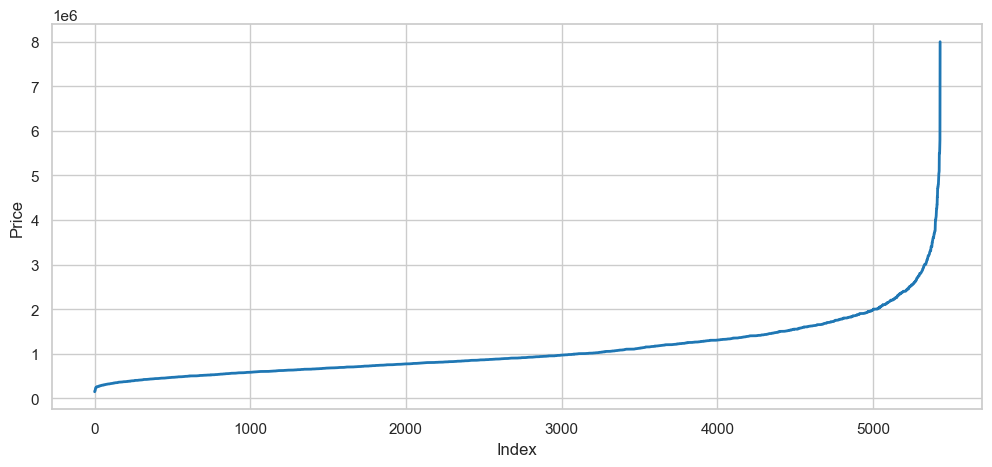

In [193]:
# sort the data by price
housing.sort_values(by=['Price'], ascending=True, inplace=True)
# reset the index
housing.reset_index(drop=True, inplace=True)
# plot x= index, y = price
plt.plot(housing['Price'])
plt.ylabel('Price')
plt.xlabel('Index')
plt.show()

As we can see from the plot above, the price follows an exponential distribution. We will apply a log transformation to the price to make it easier to work with.

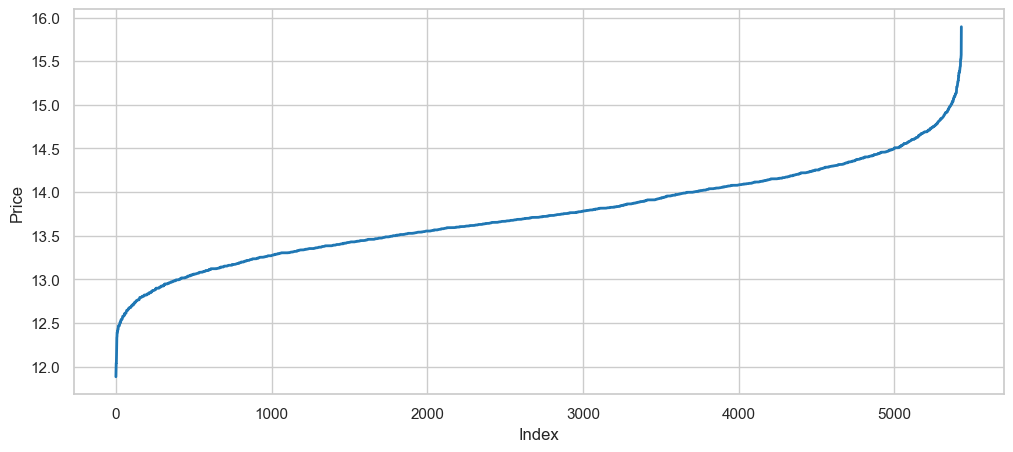

In [194]:
housing['Price'] = np.log1p(housing['Price'])
plt.plot(housing['Price'])
plt.ylabel('Price')
plt.xlabel('Index')
plt.show()

Now the outliers are more visible. We will create an attribute to indicate if a house is an outlier or not. We will consider a house to be an outlier if its price is outside of the interquartile range.

In [195]:
# calculate the interquartile range
Q1 = housing['Price'].quantile(0.25)
Q3 = housing['Price'].quantile(0.75)
IQR = Q3 - Q1
# calculate the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# create the attribute
housing['Outlier'] = np.where((housing['Price'] < lower_bound) | (housing['Price'] > upper_bound), 1, 0)

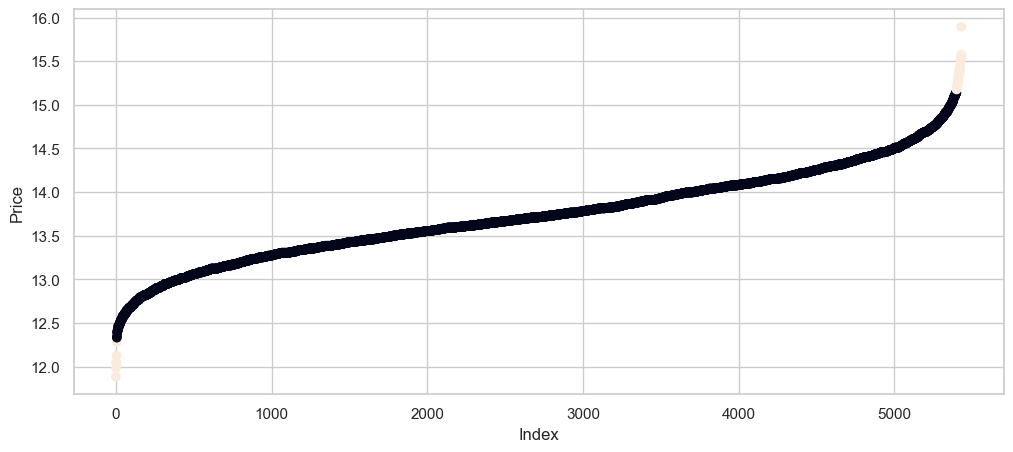

In [196]:
# plot the outliers
plt.scatter(housing.index, housing['Price'], c=housing['Outlier'])
plt.ylabel('Price')
plt.xlabel('Index')
plt.show()

We will remove the outliers above the upper bound and below the lower bound.

In [197]:
# remove the outliers
housing = housing[(housing['Outlier'] == 0)]
# reset the index
housing.reset_index(drop=True, inplace=True)
# remove the attribute
housing.drop('Outlier', axis=1, inplace=True)

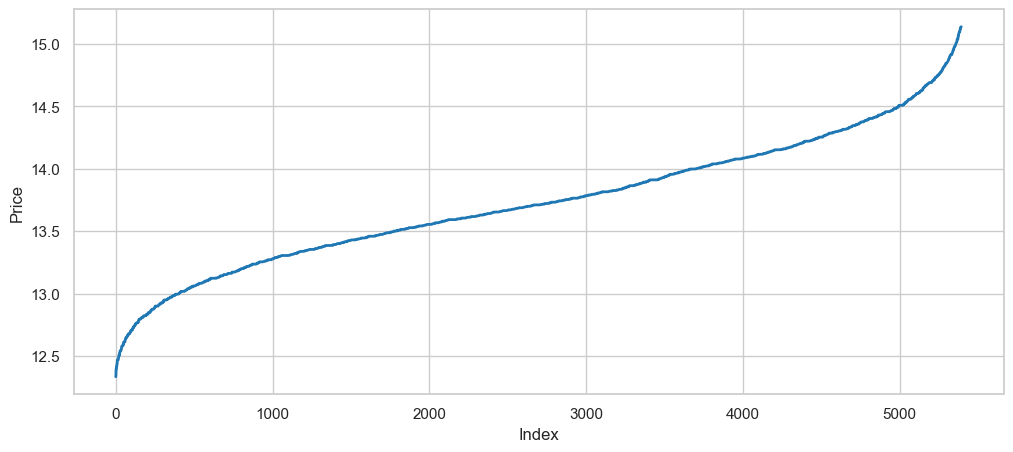

In [198]:
# plot the price again
plt.plot(housing['Price'])
plt.ylabel('Price')
plt.xlabel('Index')
plt.show()

We will now plot the histogram of the price to see its distribution after removing the outliers and applying the log transformation.

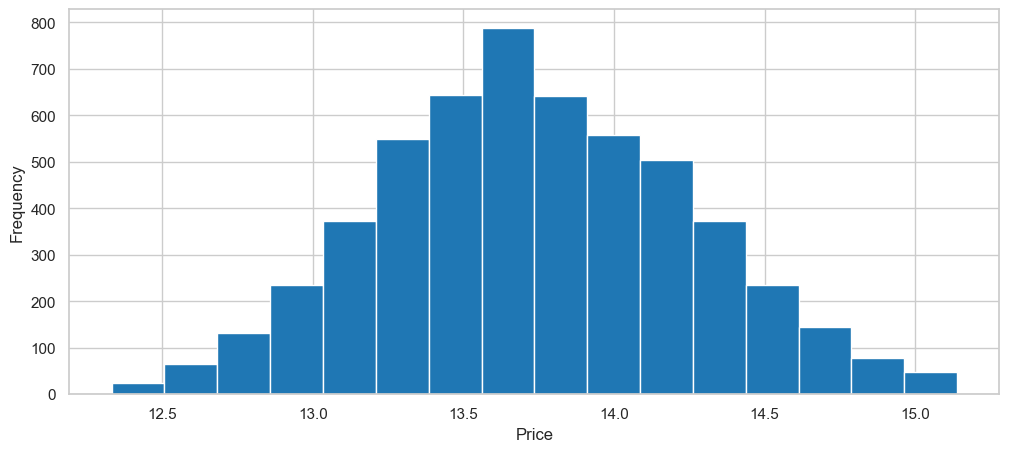

In [199]:
# plot the histogram of the price
plt.hist(housing['Price'], bins=16)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.show()

## Split data into train and validation

We split the data into train and validation sets using a stratified sampling on the price category to ensure that the distribution of prices is similar in both sets.

In [200]:
from sklearn.model_selection import StratifiedShuffleSplit

housing["price_cat"] = pd.cut(housing["Price"],
                              bins=[0., 500000, 1000000, 1500000, 2000000., np.inf],
                              labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["price_cat"]):
    train_set = housing.loc[train_index]
    validation_set = housing.loc[test_index]

for set_ in (train_set, validation_set):
    set_.drop("price_cat", axis=1, inplace=True)

price_column = train_set["Price"].copy()
price_column_val = validation_set["Price"].copy()


## Data treatment

We will plot a heatmap of the correlation matrix of the numerical columns.

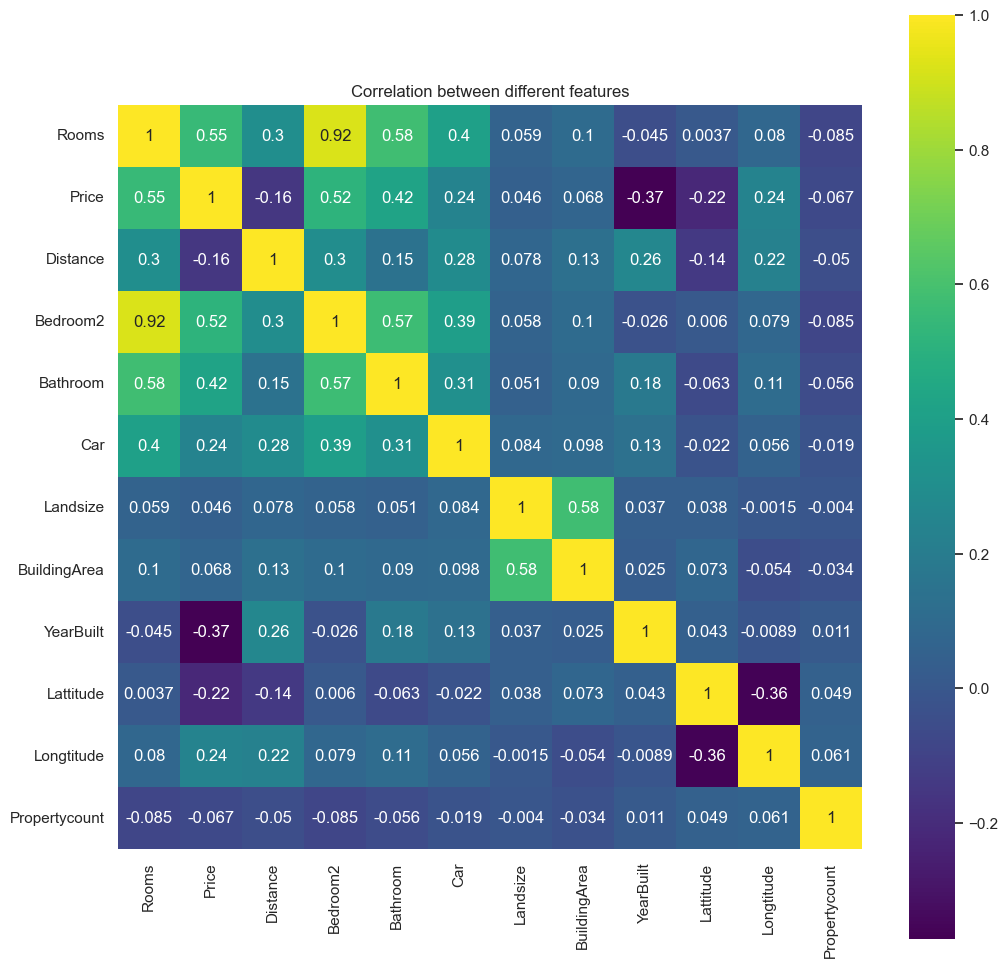

In [201]:
corr_matrix = housing.corr(numeric_only=True)
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, vmax=1, square=True, annot=True, cmap='viridis')
plt.title('Correlation between different features')
plt.show()

We will plot the histograms of the numerical features to see their distribution.

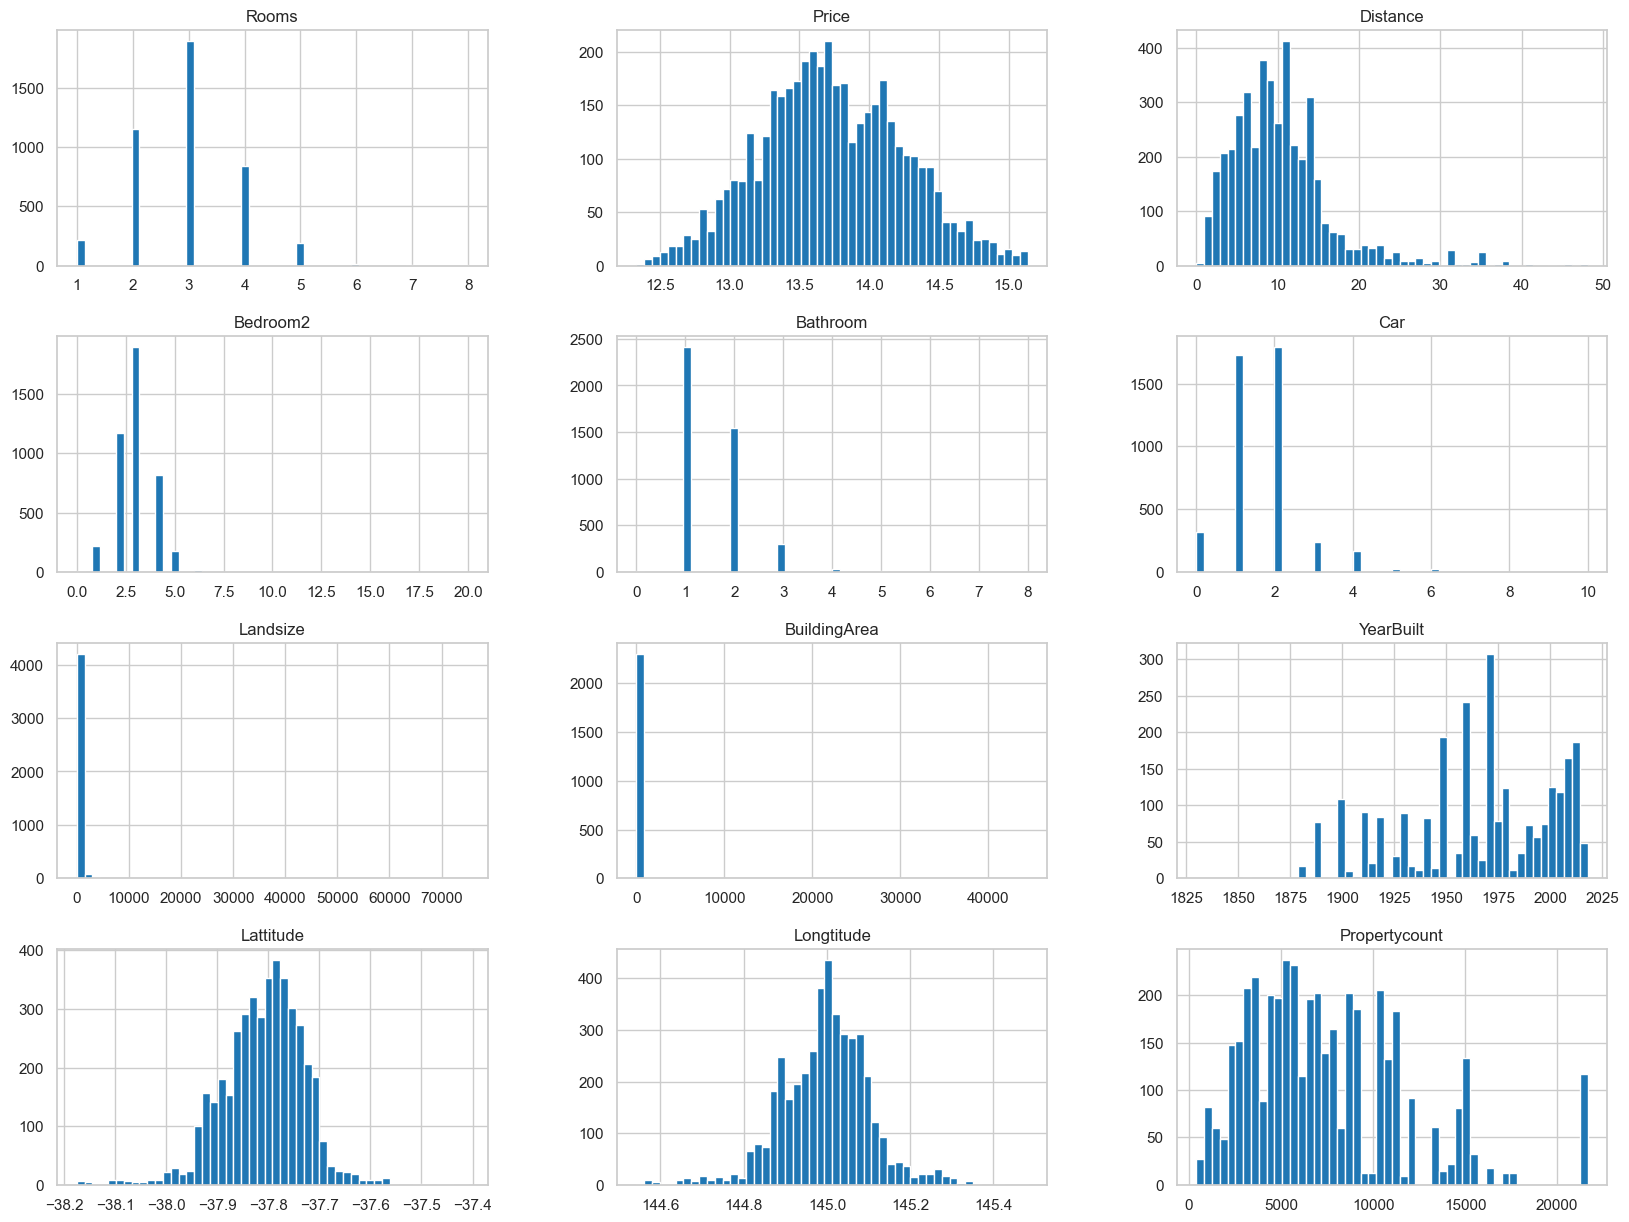

In [202]:
train_set.hist(bins=50, figsize=(20,15))
plt.show()

We will now build our Pipeline. It consists of the following:
1. Replace data errors with NaNs
2. Impute NaNs following a custom strategy
3. Apply log transformation to skewed features
4. Do some feature engineering
5. Apply standard scaling to numerical features
6. One hot encode categorical features

In [203]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

# Define custom function for imputation
def custom_imputer0(dataset):
    # Replace zeros with NaNs in 'BuildingArea' and 'Landsize' columns.
    dataset['BuildingArea'].replace(0, np.nan, inplace=True)
    dataset['Landsize'].replace(0, np.nan, inplace=True)

    # Impute 'Landsize' based on 'BuildingArea'. Fill remaining NaNs (if there are any) based on 'CouncilArea' grouping and then impute remaining NaNs based on 'Suburb' grouping and by its median.
    dataset['Landsize'] = dataset.groupby('BuildingArea')['Landsize'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['Landsize'] = dataset.groupby('CouncilArea')['Landsize'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['Landsize'] = dataset.groupby('Suburb')['Landsize'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['Landsize'] = dataset['Landsize'].fillna(dataset['Landsize'].median())

    # Impute 'BuildingArea' based on 'Landsize'. Fill remaining NaNs (if there are any) based on 'CouncilArea' grouping and then impute remaining NaNs based on 'Suburb' grouping and by its median.
    dataset['BuildingArea'] = dataset.groupby('Landsize')['BuildingArea'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['BuildingArea'] = dataset.groupby('CouncilArea')['BuildingArea'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['BuildingArea'] = dataset.groupby('Suburb')['BuildingArea'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['BuildingArea'] = dataset['BuildingArea'].fillna(dataset['BuildingArea'].median())

    # Drop 'Suburb' and 'CouncilArea' columns.
    dataset.drop(columns=['Suburb', 'CouncilArea'], inplace=True)

    return dataset

num0_pipeline = Pipeline([
    ('imputer', FunctionTransformer(func = custom_imputer0)),
    ('log', FunctionTransformer(np.log1p, validate=True)),
    ('std_scaler0', StandardScaler()),
])

num0_attributes = ['BuildingArea', 'Landsize', 'Suburb', 'CouncilArea']

# Define custom function for imputation
def custom_imputer1(dataset):
    # Impute 'YearBuilt' based on 'CouncilArea' and then impute remaining NaNs based on 'Suburb' grouping. Fill remaining NaNs (if there are any) by median.
    dataset['YearBuilt'] = dataset.groupby('CouncilArea')['YearBuilt'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['YearBuilt'] = dataset.groupby('Suburb')['YearBuilt'].transform(lambda dataset: dataset.fillna(dataset.median()))
    dataset['YearBuilt'] = dataset['YearBuilt'].fillna(dataset['YearBuilt'].median())

    # Drop 'Suburb' and 'CouncilArea' columns.
    dataset.drop(columns=['Suburb', 'CouncilArea'], inplace=True)

    return dataset

num1_pipeline = Pipeline([
    ('imputer', FunctionTransformer(func = custom_imputer1)),
    ('std_scaler1', StandardScaler()),
])

num1_attributes = ['YearBuilt', 'Suburb', 'CouncilArea']

# Define a class to add new features
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        # No fitting needed
        return self

    def transform(self, dataset):
        # Impute 'Car' based on 'Rooms' since they are the most correlated. Then impute remaining NaNs (if there are any) based on 'Suburb' grouping and by its median.
        dataset['Car'] = dataset.groupby('Rooms')['Car'].transform(lambda dataset: dataset.fillna(dataset.median()))
        dataset['Car'] = dataset.groupby('Suburb')['Car'].transform(lambda dataset: dataset.fillna(dataset.median()))
        dataset['Car'] = dataset['Car'].fillna(dataset['Car'].median())
       
        # We create the following feature by combining Rooms and Bathroom.
        dataset['TotalPonderatedRooms'] = dataset['Rooms'] * 0.8 + dataset['Bathroom'] * 0.2

        # We drop Suburb.
        dataset.drop(columns=['Suburb'], inplace=True)

        return dataset

atrib_adder_pipeline = Pipeline([
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler2', StandardScaler()),
])

atrib_adder_attributes = ['Rooms', 'Bathroom', 'Car', 'Distance', 'Suburb']

# We will use a OneHotEncoder to transform the desired categorical features into numerical ones.
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="constant",fill_value='Unknown')),
    ('one_hot_encoder', OneHotEncoder(sparse=False, handle_unknown='ignore')),
])

cat_attributes = ['Suburb', 'CouncilArea']

full_pipeline = ColumnTransformer([
    ("num0", num0_pipeline, num0_attributes),
    ("num1", num1_pipeline, num1_attributes),
    ("atrib_adder", atrib_adder_pipeline, atrib_adder_attributes),
    ("cat", cat_pipeline, cat_attributes),
])

train_set_prepared = full_pipeline.fit_transform(train_set)

train_set_prepared

C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\p

array([[-0.63231318, -0.18176692, -0.6027952 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.07904791, -0.72438861, -2.78618343, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.60367058,  0.76404843, -0.23889716, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.73333121,  0.55134731,  0.01583146, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.2755897 ,  0.61649639, -0.23889716, ...,  0.        ,
         0.        ,  0.        ],
       [-0.32817828, -0.06154194,  0.01583146, ...,  0.        ,
         0.        ,  0.        ]])

## Select and train model

As we can see in the statement, the Random Forest model works best for this problem. We will find the best parameters for it by using a Randomized Search. Then we will refine the chosen parameters by using a Grid Search, and then we will train it.

In [204]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 10, stop = 1000, num = 10)]
# Number of features to consider at every split
max_features = ['log2', 'sqrt', 10, 25]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(1, 100, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [10, 20, 50]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 10, 50]
# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

random_grid

{'n_estimators': [10, 120, 230, 340, 450, 560, 670, 780, 890, 1000],
 'max_features': ['log2', 'sqrt', 10, 25],
 'max_depth': [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'min_samples_split': [10, 20, 50],
 'min_samples_leaf': [1, 10, 50],
 'bootstrap': [True, False]}

We use the random grid to search for the best hyperparameters from the ones above, doing a 3-fold cross validation, searching across 50 different combinations, and using all available cores.

In [205]:
grid_search = RandomizedSearchCV(estimator = RandomForestRegressor(random_state=42), 
                               param_distributions = random_grid, 
                               n_iter = 50, cv = 3, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
grid_search.fit(train_set_prepared, price_column)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [1, 10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, None],
                                        'max_features': ['log2', 'sqrt', 10,
                                                         25],
                                        'min_samples_leaf': [1, 10, 50],
                                        'min_samples_split': [10, 20, 50],
                                        'n_estimators': [10, 120, 230, 340, 450,
                                                         560, 670, 780, 890,
                                                         1000]},
                   random_state=42, verbose=2)

In [206]:
print("the best parameters are:")
print(grid_search.best_params_)

the best parameters are:
{'n_estimators': 670, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 25, 'max_depth': 50, 'bootstrap': False}


To determine if random search yielded a better model, we compare the base model with the best random search model.

In [207]:
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    mape = 100 * np.mean(errors / test_labels)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(accuracy))
    
    return accuracy

base_model = RandomForestRegressor(n_estimators = 10, random_state = 42)
base_model.fit(train_set_prepared, price_column)
base_accuracy = evaluate(base_model, train_set_prepared, price_column)

best_random = grid_search.best_estimator_
random_accuracy = evaluate(best_random, train_set_prepared, price_column)

print('Improvement of {:0.2f}%.'.format( 100 * (random_accuracy - base_accuracy) / base_accuracy))

Model Performance
Average Error: 0.0917 degrees.
Accuracy = 99.33%.
Model Performance
Average Error: 0.1079 degrees.
Accuracy = 99.22%.
Improvement of -0.12%.


In [208]:
print("the best random trained model:")
grid_search.best_estimator_

the best random trained model:


RandomForestRegressor(bootstrap=False, max_depth=50, max_features=25,
                      min_samples_split=10, n_estimators=670, random_state=42)

Use the root mean squared error to evaluate the model on the training set

In [209]:
from sklearn.metrics import mean_squared_error

housing_predictions = grid_search.predict(train_set_prepared)
forest_mse = mean_squared_error(price_column, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

0.1451825860720892

In [210]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(RandomForestRegressor(bootstrap=False, random_state=42),
                           param_grid={'n_estimators': [75, 150, 500], 'max_features': [20, 25, 30], 'max_depth': [None, 30, 60]},
                           scoring='neg_root_mean_squared_error', return_train_score=True, cv=3, n_jobs=-1)
grid_search.fit(train_set_prepared, price_column)

GridSearchCV(cv=3,
             estimator=RandomForestRegressor(bootstrap=False, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 30, 60],
                         'max_features': [20, 25, 30],
                         'n_estimators': [75, 150, 500]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [211]:
print("the best parameters are:")
print(grid_search.best_params_)

the best parameters are:
{'max_depth': 30, 'max_features': 20, 'n_estimators': 500}


In [212]:
base_model = RandomForestRegressor(n_estimators=10, random_state=42)
base_model.fit(train_set_prepared, price_column)
base_accuracy = evaluate(base_model, train_set_prepared, price_column)

best_grid_model = grid_search.best_estimator_
random_accuracy = evaluate(best_grid_model, train_set_prepared, price_column)

print('Improvement of {:0.2f}%.'.format(100 * (random_accuracy - base_accuracy) / base_accuracy))

Model Performance
Average Error: 0.0917 degrees.
Accuracy = 99.33%.
Model Performance
Average Error: 0.0712 degrees.
Accuracy = 99.48%.
Improvement of 0.15%.


In [213]:
print("the best random trained model:")
grid_search.best_estimator_

the best random trained model:


RandomForestRegressor(bootstrap=False, max_depth=30, max_features=20,
                      n_estimators=500, random_state=42)

In [214]:
housing_predictions = grid_search.predict(train_set_prepared)
forest_mse = mean_squared_error(price_column, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

0.1068809314810204

After performing several hyperparameter testing with Kaggle submissions, we found that the following parameters yield the best results:

In [215]:
from sklearn.metrics import mean_squared_error

best_model = RandomForestRegressor(bootstrap=False, max_features=20, n_estimators=75, random_state=42)
best_model.fit(train_set_prepared, price_column)
accuracy = evaluate(best_model, train_set_prepared, price_column)

print('Improvement of {:0.2f}%.'.format( 100 * (accuracy - base_accuracy) / base_accuracy))

housing_predictions = best_model.predict(train_set_prepared)
forest_mse = mean_squared_error(price_column, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

Model Performance
Average Error: 0.0220 degrees.
Accuracy = 99.84%.
Improvement of 0.51%.


0.07332305327487308

 ## Final Model

Our final model is the Random Forest model with the best parameters.

In [216]:
final_model = RandomForestRegressor(bootstrap=False, max_features=20, n_estimators=75, random_state=42)

# Fit the model
final_model.fit(train_set_prepared, price_column)

# Prepare validation set in order to apply our model
validation_set_prepared = full_pipeline.transform(validation_set)

# Predict with model
final_predictions = final_model.predict(validation_set_prepared)

# Compare results
final_mse = mean_squared_error(price_column_val, final_predictions)
final_rmse = np.sqrt(final_mse)
print(final_rmse)

0.2850121617484523


C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\p

We conclude that our model is accurate. Now, we must train the model with the whole dataset.

In [217]:
final_model = RandomForestRegressor(bootstrap=False, max_features=20, n_estimators=75, random_state=42)

price_column_housing = housing["Price"].copy()
# Apply Pipeline to whole dataset
housing_prepared = full_pipeline.fit_transform(housing)

# Fit the model
final_model.fit(housing_prepared, price_column_housing)

# Read test set and predict with our model
test_set = pd.read_csv('test_set.csv', index_col=0)
test_set_prepared = full_pipeline.transform(test_set)
final_predictions = final_model.predict(test_set_prepared)

# As we are predicting with the log of the prices, we must now do an exponential transformation to the predicted price column.
df_output = pd.DataFrame(final_predictions)
df_output = df_output.reset_index()
df_output.columns = ['index','Price']

df_output['Price'] = df_output['Price'].apply(lambda x: np.e**x)

df_output.to_csv('output/session2/submission.csv',index=False)

C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\p

## Boosting

We will now try to improve our model by using boosting. We will use XGBoost.

In [218]:
from xgboost import XGBRegressor

XGB_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05)
XGB_reg.fit(train_set_prepared, price_column,
            early_stopping_rounds=5,
            eval_set=[(train_set_prepared, price_column)],
            verbose=False)

C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py:885: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Use the root mean squared error to evaluate the model on the training set

In [219]:
housing_predictions = XGB_reg.predict(validation_set_prepared)
XGB_mse = mean_squared_error(price_column_val, housing_predictions)
XGB_rmse = np.sqrt(XGB_mse)
print("XGBoost RMSE on validation set:", XGB_rmse)

XGBoost RMSE on validation set: 0.2882879455257222


Now we will train the model with the whole dataset and predict the price of the houses in the test set.

In [220]:
from xgboost import XGBRegressor

XGB_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05)
XGB_reg.fit(housing_prepared, price_column_housing,
             early_stopping_rounds=5,
             eval_set=[(housing_prepared, price_column_housing)],
             verbose=False)

C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py:885: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [221]:
housing_predictions = XGB_reg.predict(test_set_prepared)
df_output = pd.DataFrame(housing_predictions)
df_output = df_output.reset_index()
df_output.columns = ['index','Price']

df_output['Price'] = df_output['Price'].apply(lambda x: np.e**x)

df_output.to_csv('output/session2/boostedSubmission.csv',index=False)